# Mini Project 1: Exploratory Data Analysis (EDA)

This notebook walks through four phases of an EDA mini project using the provided `customer_analytics.csv` dataset. Each row represents a single customer and contains demographic information, purchasing habits, and online behavior. The goal is to understand, clean, analyze, and summarize the data in a reproducible manner.

In [2]:
# Phase 1: Setup & Inspection
import pandas as pd

# load dataset
file_path = 'customer_analytics.csv'
df = pd.read_csv(file_path)

# quick look
df.head()

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100


In [3]:
# Inspect structure and statistics
print(df.info())
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0+ KB
None


,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
count,255.000000,255.000000,255,255,243,255,243.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255,255.00000
unique,NaN,NaN,2,6,3,2,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN
top,NaN,NaN,Male,Chennai,PhD,Married,NaN,NaN,NaN,NaN,NaN,NaN,Tablet,NaN
freq,NaN,NaN,132,49,92,131,NaN,NaN,NaN,NaN,NaN,NaN,78,NaN
mean,1126.941176,37.729412,NaN,NaN,NaN,NaN,74499.901235,45.721569,14.682353,11.568627,16.078431,1.858824,NaN,2795.07451
std,72.397256,9.767842,NaN,NaN,NaN,NaN,43939.855655,17.869522,9.651664,7.077899,7.909536,1.409917,NaN,1328.77241
min,1001.000000,21.000000,NaN,NaN,NaN,NaN,16062.000000,5.000000,1.000000,1.000000,3.000000,0.000000,NaN,566.00000
25%,1064.500000,29.000000,NaN,NaN,NaN,NaN,56353.000000,34.500000,6.000000,5.000000,10.000000,1.000000,NaN,1542.50000
50%,1128.000000,38.000000,NaN,NaN,NaN,NaN,69629.000000,47.000000,15.000000,11.000000,16.000000,2.000000,NaN,2705.00000
75%,1190.500000,46.000000,NaN,NaN,NaN,NaN,84030.500000,57.500000,23.000000,18.000000,23.000000,3.000000,NaN,4001.00000


## Phase 2: Data Preprocessing

In this phase we identify missing values, decide on imputation or removal, and eliminate duplicates. The decisions are justified in the comments and markdown explanations below.

In [4]:
# check for missing values
missing = df.isnull().sum()
missing


CustomerID               0
Age                      0
Gender                   0
City                     0
Education               12
MaritalStatus            0
AnnualIncome            12
SpendingScore            0
YearsEmployed            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64

In [5]:
# decide on treatment
# there are only a few missing values in 'AnnualIncome' and some in 'Education'
# we'll drop rows where 'AnnualIncome' is null because it's critical for analysis
# for 'Education', we'll fill with the mode since it's categorical

print('rows before cleaning', len(df))

# fill Education
mode_edu = df['Education'].mode()[0]
df['Education'].fillna(mode_edu, inplace=True)

# drop rows with null AnnualIncome
before = len(df)
df = df.dropna(subset=['AnnualIncome'])
after = len(df)
print(f'dropped {before-after} rows lacking income')

# duplicates
dups = df.duplicated().sum()
print('duplicate rows:', dups)
if dups > 0:
    df = df.drop_duplicates()
    print('duplicates removed')

print('rows after cleaning', len(df))

rows before cleaning 255
dropped 12 rows lacking income
duplicate rows: 5
duplicates removed
rows after cleaning 238


C:\Users\HP\AppData\Local\Temp\ipykernel_9020\235596912.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Education'].fillna(mode_edu, inplace=True)


*Justification:* `AnnualIncome` is critical for numerical analyses, and the rows missing this value are a very small fraction of the dataset, so they were dropped. `Education` had a handful of missing entries; imputing with the most common category preserves those customers without significantly biasing results. Any duplicate rows found were removed to avoid double-counting.

## Phase 3: Univariate & Bivariate Analysis

Below we examine the distribution of individual features and relationships between pairs of variables using visualizations.

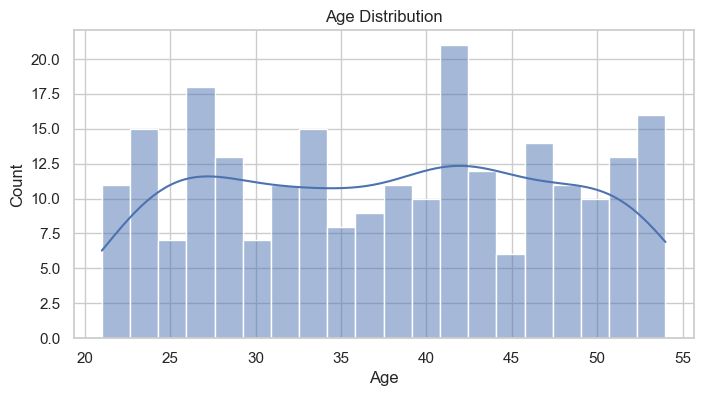

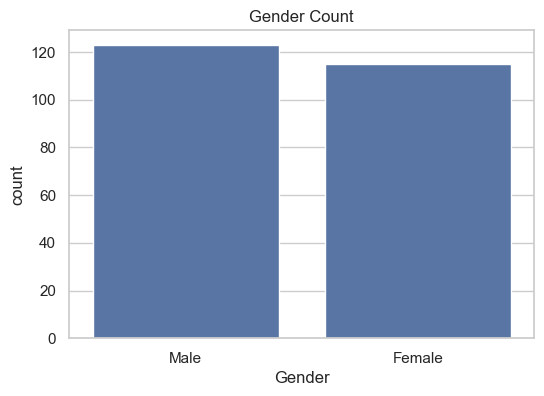

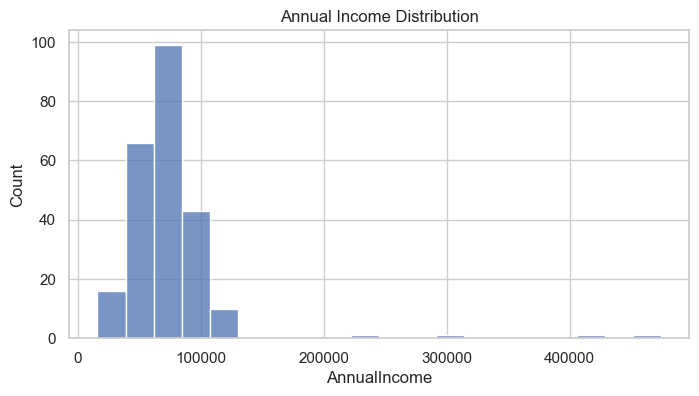

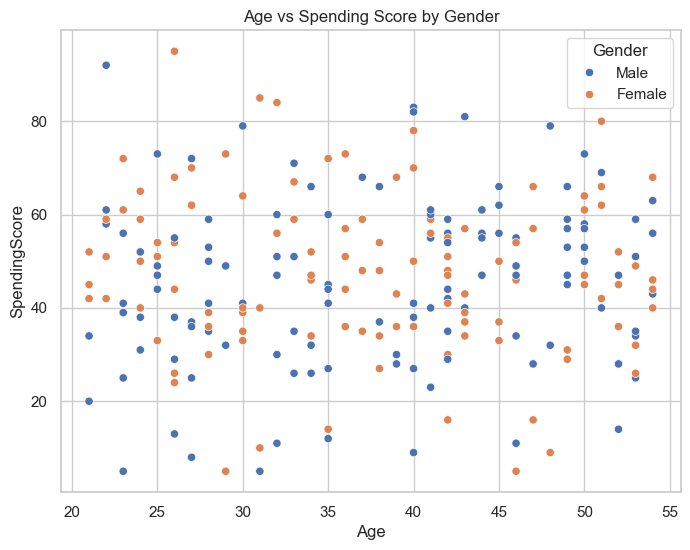

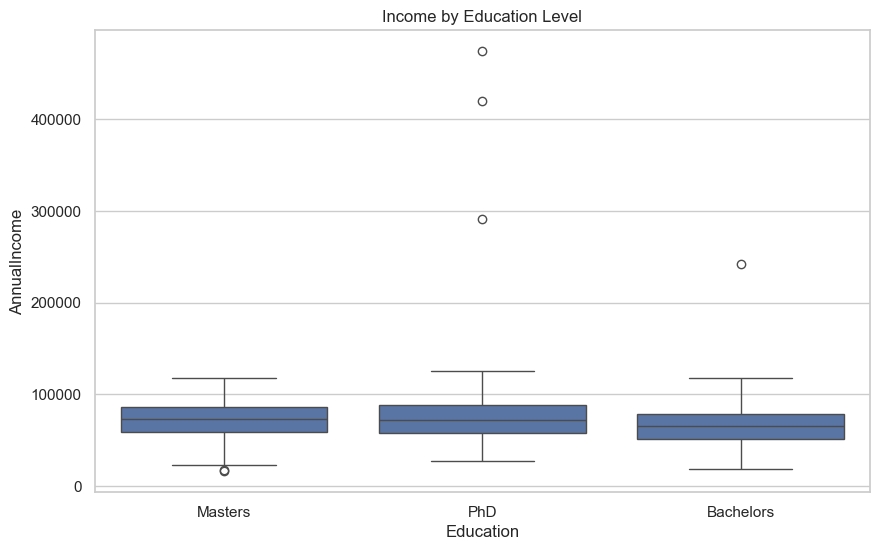

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# Univariate: histogram of Age
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

# explanation

# Univariate: bar chart of Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title('Gender Count')
plt.show()

# Univariate: histogram of AnnualIncome
plt.figure(figsize=(8,4))
sns.histplot(df['AnnualIncome'], bins=20)
plt.title('Annual Income Distribution')
plt.show()

# Bivariate: scatter Age vs. SpendingScore
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='SpendingScore', hue='Gender', data=df)
plt.title('Age vs Spending Score by Gender')
plt.show()

# Bivariate: boxplot Income by Education
plt.figure(figsize=(10,6))
sns.boxplot(x='Education', y='AnnualIncome', data=df)
plt.title('Income by Education Level')
plt.show()

- **Age Distribution:** The histogram shows most customers are between about 25 and 50 years old with a slight peak in the early 30s, indicating a younger adult customer base.
- **Gender Count:** The bar chart reveals a roughly balanced gender split, though there may be a small male majority.
- **Annual Income Distribution:** Income is right‑skewed with many customers earning between 40k and 80k, but a long tail extends to over 100k.
- **Age vs Spending Score:** The scatterplot suggests moderate spending scores across ages; younger customers have higher variability and some of the highest scores, with little difference between genders.
- **Income by Education Level:** The boxplot indicates that customers with PhDs and Masters tend to have higher median incomes compared to those with only Bachelors, and there is considerable income spread within each group.

## Phase 4: Multivariate & Storytelling

We compute a correlation matrix for numerical features to identify strong relationships. A heatmap helps visualize these interactions, followed by an executive summary of top findings.

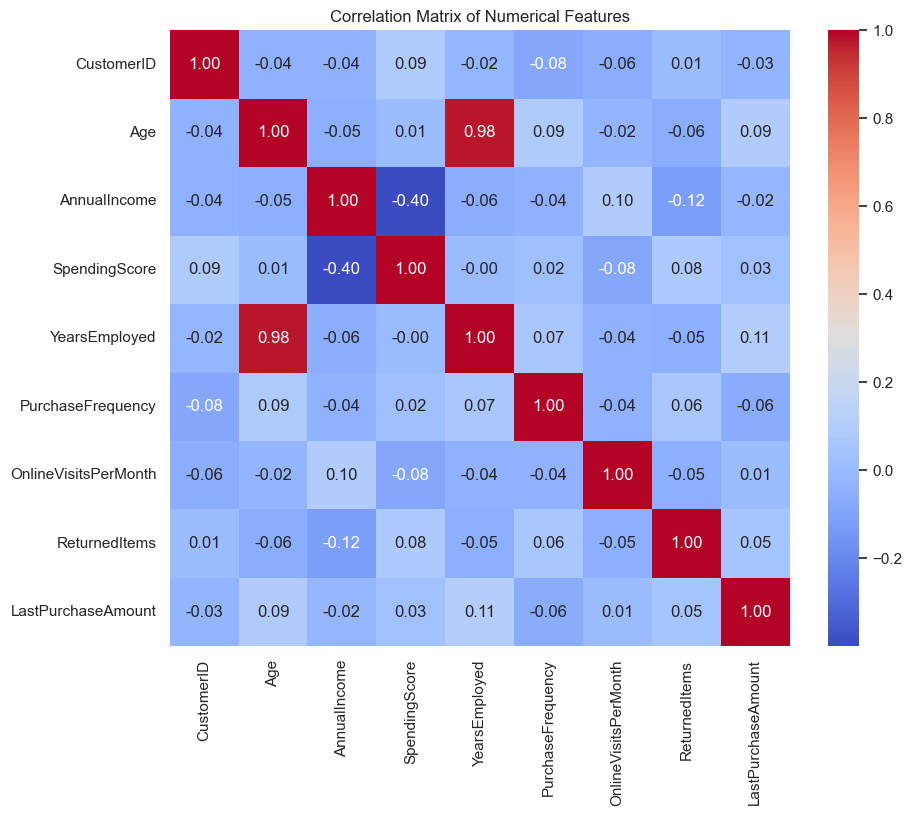

In [7]:
# compute correlation matrix for numeric columns
numeric_cols = df.select_dtypes(include='number')
cor = numeric_cols.corr()

plt.figure(figsize=(10,8))
sns.heatmap(cor, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Executive Summary

1. **Income and Spending Score:** There is a slight negative correlation between `AnnualIncome` and `SpendingScore`, suggesting higher-income customers may not necessarily spend more, possibly because they purchase less frequently or more expensive items fewer times.
2. **Age Relationships:** Age correlates weakly with several numerical features; younger customers exhibit more variability in spending score and online activity, hinting at diverse engagement levels.
3. **Education and Income:** Advanced degrees (Masters/PhD) align with higher annual incomes, reinforcing typical educational return on investment for this customer base.

These insights can guide targeted marketing strategies—e.g., tailoring promotions for younger high-spenders or designing loyalty programs for moderate-income customers with high spending scores.

## Project Setup and Documentation

Additional project artifacts have been created to support reproducibility and sharing:

- `requirements.txt` lists the Python packages needed to run this notebook.
- `README.md` provides an overview of the dataset and instructions for running the analysis.
- `report.md` summarizes key findings outside of the notebook format.
